In [10]:
import os
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# --- Cell 1 Modification ---
class CamusTemporalDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # Hna na77ina el [:10] bach y-loadi ga3 el database (Full Dataset)
        self.patients = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.pairs = []
        for p in self.patients:
            p_path = os.path.join(root_dir, p)
            for view in ['2CH', '4CH']:
                ed_file = os.path.join(p_path, f"{p}_{view}_ED.nii.gz")
                es_file = os.path.join(p_path, f"{p}_{view}_ES.nii.gz")
                if os.path.exists(ed_file) and os.path.exists(es_file):
                    self.pairs.append((ed_file, es_file))
        print(f"✅ Full Dataset Loaded: {len(self.pairs)} Positive Pairs found.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ed_path, es_path = self.pairs[idx]
        
        # 1. Load NIfTI images (get_fdata yred'ha numpy array)
        ed_img = nib.load(ed_path).get_fdata().astype(np.float32)
        es_img = nib.load(es_path).get_fdata().astype(np.float32)
        
        # 2. Normalization simple (0 to 1)
        ed_img = (ed_img - np.min(ed_img)) / (np.max(ed_img) + 1e-8)
        es_img = (es_img - np.min(es_img)) / (np.max(es_img) + 1e-8)

        # 3. Convert to Tensors (Batch, Channel, H, W)
        # Unsqueeze(0) bach n-zidu el Channel dimension
        ed_tensor = torch.from_numpy(ed_img).unsqueeze(0)
        es_tensor = torch.from_numpy(es_img).unsqueeze(0)

        # 4. Apply Augmentations (Flipping, Rotation, Jitter)
        # Hna n-generi "Views" kima 9al el encadreur
        if self.transform:
            view_ed = self.transform(ed_tensor)
            view_es = self.transform(es_tensor)
            return view_ed, view_es
            
        return ed_tensor, es_tensor

# Test el setup m3a el GPU ta3ek
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device detected: {device}")

✅ Device detected: cuda


In [11]:
# 1. Defining the Augmentations
# Hada el "Transformation Pipeline" li ghadi ybedel chwiya f tswira
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5), # Flipping
    T.RandomVerticalFlip(p=0.5),   # Flipping
    T.RandomRotation(degrees=15),  # Rotation
    T.ColorJitter(brightness=0.2, contrast=0.2), # Brightness Jitter
    # T9dar tzid Resize ida l-images machi nafss el size
    T.Resize((256, 256)) 
])

# 2. Initializing the Dataset
# Beddel 'path/to/camus' b el path el s7i7 f el PC ta3ek
dataset = CamusTemporalDataset(root_dir=r'C:/Users/najib/OneDrive/Bureau/camus_project/database', transform=train_transform)

# 3. Setting up the DataLoader
# Radd 'num_workers' l-el 0 bach may-crashich f Windows
train_loader = DataLoader(
    dataset, 
    batch_size=16, 
    shuffle=True, 
    num_workers=0  # <--- Hna saggemha
)

# Test l'affichage
try:
    view_ed, view_es = next(iter(train_loader))
    print(f"✅ Batch loaded successfully!")
    print(f"✅ View ED Shape: {view_ed.shape}") 
    print(f"✅ View ES Shape: {view_es.shape}")
except Exception as e:
    print(f"❌ Error: {e}")

✅ Full Dataset Loaded: 1000 Positive Pairs found.
✅ Batch loaded successfully!
✅ View ED Shape: torch.Size([16, 1, 256, 256])
✅ View ES Shape: torch.Size([16, 1, 256, 256])


In [12]:
import tkinter as tk
from tkinter import filedialog
import os

# 1. Open a window to select the CAMUS dataset folder
root = tk.Tk()
root.withdraw() # Hide the main window
root.attributes("-topmost", True) # Bring the dialog to the front

print("--- Please select the CAMUS dataset folder ---")
selected_path = filedialog.askdirectory()

if selected_path:
    print(f"✅ Your correct path is: r'{selected_path}'")
    # Verify if it contains patient folders
    content = os.listdir(selected_path)
    print(f"   Found {len(content)} items inside this folder.")
else:
    print("❌ No folder selected.")

--- Please select the CAMUS dataset folder ---
❌ No folder selected.


In [13]:
import torch.nn as nn
# Lazem t-installer pykan ida mahich 3andek: !pip install pykan
from kan import KAN 

class SSL_KAN_Model(nn.Module):
    def __init__(self, backbone_out_dim=512):
        super(SSL_KAN_Model, self).__init__()
        
        # 1. El Encoder ta3ek (Backbone)
        # N-assumou testa3mel U-Net encoder li ykharaj 512 features
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        ) 
        
        # 2. Position 1: SSL Projection Head (MLP replaced by KAN)
        # El encadreur 9al: replace 2-layer MLP with KAN
        # [Input, Hidden, Output]
        self.projection_head = KAN([64, 128, 256]) 

    def forward(self, x):
        features = self.encoder(x)
        projected_features = self.projection_head(features)
        return projected_features

# 3. Transfer to RTX 3060
model = SSL_KAN_Model().to("cuda")
print("✅ Model loaded on RTX 3060 with KAN Projection Head (Position 1)")

checkpoint directory created: ./model
saving model version 0.0
✅ Model loaded on RTX 3060 with KAN Projection Head (Position 1)


In [9]:
import torch.optim as optim
import torch.nn.functional as F

# 1. Hyperparameters (Saggemnahlhom l-el-Long Run)
epochs = 100 # <--- Modifiée l-100 kima tfahemna
lr = 1e-4 
weight_decay = 1e-2 
best_ssl_loss = float('inf') # <--- Bach n-trackiw a7san natija

optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

print(f"🚀 Starting Step 1: Full Pretraining on RTX 3060 for {epochs} epochs...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for batch_idx, (view_ed, view_es) in enumerate(train_loader):
        view_ed = view_ed.to("cuda")
        view_es = view_es.to("cuda")
        
        optimizer.zero_grad()
        
        z_ed = model(view_ed)
        z_es = model(view_es)
        
        # Loss: Negative Cosine Similarity
        loss = -F.cosine_similarity(z_ed, z_es).mean()
        
        if torch.isnan(loss):
            print(f"❌ Instability detected at Epoch {epoch}! Skipping...")
            continue # <--- Skip fi blaset break bach ma y-habasouch el-khedma ga3
            
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    
    # 💾 CHECKPOINT LOGIC: Sauvgardi ghir ida kanet el-loss mliha
    if avg_loss < best_ssl_loss:
        best_ssl_loss = avg_loss
        torch.save(model.state_dict(), 'best_ssl_kan_model.pth')
        save_msg = "⭐ Best Model Saved!"
    else:
        save_msg = ""

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f} {save_msg}")

print(f"✅ Pretraining Position 1 Complete! Best Loss reached: {best_ssl_loss:.4f}")

🚀 Starting Step 1: Full Pretraining on RTX 3060 for 100 epochs...
Epoch [1/100] - Loss: -0.9998 ⭐ Best Model Saved!
Epoch [5/100] - Loss: -1.0000 ⭐ Best Model Saved!


KeyboardInterrupt: 

In [14]:
class EF_Regression_Model(nn.Module):
    def __init__(self, pretrained_model):
        super(EF_Regression_Model, self).__init__()
        # 1. N-asta3mlou el Encoder li traininah f Position 1
        self.encoder = pretrained_model.encoder
        
        # 2. Freeze el encoder (Backbone) bach n-focusiw ghir 3la el EF
        for param in self.encoder.parameters():
            param.requires_grad = False
            
        # 3. Position 2: Small KAN for EF Regression
        # Bottleneck features (64) -> Hidden (32) -> Output (1 value for EF)
        self.ef_head = KAN([64, 32, 1])

    def forward(self, x):
        with torch.no_grad(): # Speed up f el backbone
            features = self.encoder(x)
        ef_prediction = self.ef_head(features)
        return ef_prediction

# Initialize el model ej-jdid
final_model = EF_Regression_Model(model).to("cuda")
print("✅ Position 2: EF Regression KAN Head is ready on RTX 3060!")

checkpoint directory created: ./model
saving model version 0.0
✅ Position 2: EF Regression KAN Head is ready on RTX 3060!


In [21]:
import torch.nn as nn
import torch.nn.functional as F

class SegmentationModel(nn.Module):
    def __init__(self, pretrained_encoder):
        super(SegmentationModel, self).__init__()
        # 1. N-asta3mlou el Encoder li t3alam el anatomy
        self.encoder = pretrained_encoder.encoder
        
        # 2. Decoder (Simple Blocks bach n-reconstructi el Mask)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=1) # 1 Channel for Binary Mask
        )

    def forward(self, x):
        features = self.encoder(x)
        # N-raddou el features l-el shape (1, 1) -> (64, 1, 1) bach n-decodiw
        # Note: Hna lazem n-adaptiw el features shape l-el decoder
        x_decoded = self.decoder(features.view(-1, 64, 1, 1))
        # Interpolate bach n-raddouha 256x256
        mask = F.interpolate(x_decoded, size=(256, 256), mode='bilinear')
        return mask

# Initialize el model
seg_model = SegmentationModel(model).to("cuda")
print("✅ Ready for Fine-tuning: Encoder from Position 1 is linked to Decoder.")

✅ Ready for Fine-tuning: Encoder from Position 1 is linked to Decoder.


In [24]:
import torch
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
import numpy as np
import os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# 1. Dataset Class Definition
class SegmentationDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.patients = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.samples = []
        for p in self.patients:
            p_path = os.path.join(root_dir, p)
            for view in ['2CH', '4CH']:
                for cycle in ['ED', 'ES']:
                    img_f = os.path.join(p_path, f"{p}_{view}_{cycle}.nii.gz")
                    mask_f = os.path.join(p_path, f"{p}_{view}_{cycle}_gt.nii.gz")
                    if os.path.exists(img_f) and os.path.exists(mask_f):
                        self.samples.append((img_f, mask_f))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        img = nib.load(img_path).get_fdata().astype(np.float32)
        mask = nib.load(mask_path).get_fdata().astype(np.float32)
        img = (img - np.min(img)) / (np.max(img) + 1e-8)
        img_t = torch.from_numpy(img).unsqueeze(0)
        mask_t = torch.from_numpy(mask).unsqueeze(0)
        img_t = F.interpolate(img_t.unsqueeze(0), size=(256, 256)).squeeze(0)
        mask_t = F.interpolate(mask_t.unsqueeze(0), size=(256, 256), mode='nearest').squeeze(0)
        return img_t, mask_t

# --- HNA HOWA EL-CODE EL-JDID (L-BLASA EL-SA7I7A) ---

# A. N-creyiw el-model ta3 el-Position 1 (SSL)
# T-aked m ism el-class ta3 el-model el-asli (SSL_KAN_Model)
base_model = SSL_KAN_Model() 

# B. Loadiw el-knowledge (weights)
base_model.load_state_dict(torch.load('best_ssl_kan_model.pth'))

# C. Dorka n-passiwah l-el-Segmentation Model bach yedi el-encoder
seg_model = SegmentationModel(base_model)
seg_model.to("cuda")

print("💎 Knowledge from Position 1 (SSL) Loaded successfully into Segmentation Model!")

# ----------------------------------------------------

# 2. Setup Data & Optimizer
path_database = r'C:/Users/najib/OneDrive/Bureau/camus_project/database'
seg_dataset = SegmentationDataset(root_dir=path_database)
seg_loader = DataLoader(seg_dataset, batch_size=16 , shuffle=True)
optimizer = optim.Adam(seg_model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

# 3. Fine-tuning Loop
epochs_seg = 50
best_seg_loss = float('inf')

print("🚀 Starting Step 2: Fine-tuning for Segmentation...")

for epoch in range(epochs_seg):
    seg_model.train()
    total_loss = 0
    for imgs, masks in seg_loader:
        imgs, masks = imgs.to("cuda"), masks.to("cuda")
        optimizer.zero_grad()
        outputs = seg_model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(seg_loader)
    
    if avg_loss < best_seg_loss:
        best_seg_loss = avg_loss
        torch.save(seg_model.state_dict(), 'best_segmentation_model.pth')
        save_msg = "⭐ Best Segmentation Model Saved!"
    else:
        save_msg = ""

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs_seg}] - Loss: {avg_loss:.4f} {save_msg}")

print(f"✅ Step 2 Complete! Best Loss: {best_seg_loss:.4f}")

checkpoint directory created: ./model
saving model version 0.0


C:\Users\najib\AppData\Local\Temp\ipykernel_6068\2545666639.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base_model.load_state_dict(torch.load('best_ssl_kan_model.pt

💎 Knowledge from Position 1 (SSL) Loaded successfully into Segmentation Model!
🚀 Starting Step 2: Fine-tuning for Segmentation...
Epoch [1/50] - Loss: 0.6822 ⭐ Best Segmentation Model Saved!
Epoch [5/50] - Loss: 0.6544 ⭐ Best Segmentation Model Saved!
Epoch [10/50] - Loss: 0.6541 ⭐ Best Segmentation Model Saved!
Epoch [15/50] - Loss: 0.6540 ⭐ Best Segmentation Model Saved!
Epoch [20/50] - Loss: 0.6539 ⭐ Best Segmentation Model Saved!
Epoch [25/50] - Loss: 0.6539 ⭐ Best Segmentation Model Saved!
Epoch [30/50] - Loss: 0.6538 
Epoch [35/50] - Loss: 0.6537 ⭐ Best Segmentation Model Saved!
Epoch [40/50] - Loss: 0.6536 ⭐ Best Segmentation Model Saved!
Epoch [45/50] - Loss: 0.6536 ⭐ Best Segmentation Model Saved!
Epoch [50/50] - Loss: 0.6535 
✅ Step 2 Complete! Best Loss: 0.6535


In [25]:
import torch
import torch.nn as nn

# 1. Architecture ta3 el-KAN Regression
# Hna n-asta3mlou el-features li kharjou m el-encoder bach n-predictiw el-EF
class EFRegressionKAN(nn.Module):
    def __init__(self, pretrained_seg_model):
        super(EFRegressionKAN, self).__init__()
        self.encoder = pretrained_seg_model.encoder
        
        # KAN Layer: Hna win tji el-9owa ta3 Kolmogorov-Arnold
        # In: 64 features, Out: 1 (EF value)
        # Note: Ida rak m-installer 'kan' library, n9edrou n-diirou KANLayer
        self.regression_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Output hwa el-EF percentage
        )

    def forward(self, x_ed, x_es):
        # N-extractiw el-features m el-ED frame w el-ES frame
        feat_ed = self.encoder(x_ed)
        feat_es = self.encoder(x_es)
        
        # Combined features (Difference bin el-volumes)
        combined_feats = feat_ed - feat_es 
        
        ef_val = self.regression_head(combined_feats)
        return ef_val

# 2. Setup el-Model m3a el-Weights ta3 Step 2
# Lazem n-loadiw el-weights li jebnahom m el-segmentation
ef_model = EFRegressionKAN(seg_model).to("cuda")
print("🚀 KAN Regression Model is ready with Segmentation Knowledge!")

# 3. Optimizer l-el-EF (Learning rate sghir bach ma n-fesduch el-encoder)
optimizer_ef = torch.optim.Adam(ef_model.parameters(), lr=1e-5)
criterion_ef = nn.MSELoss() # Mean Squared Error l-el-regression

🚀 KAN Regression Model is ready with Segmentation Knowledge!


In [29]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
import numpy as np
import torch.nn.functional as F

# 1. Function bach n-le99tou el-EF m el-files .cfg
def get_ef_from_cfg(patient_path, view='2CH,4CH'):
    cfg_path = os.path.join(patient_path, f"Info_{view}.cfg")
    if os.path.exists(cfg_path):
        with open(cfg_path, 'r') as f:
            for line in f:
                if "EF:" in line:
                    return float(line.split(":")[1].strip())
    return None

# 2. Dataset el-m-modifi bach yedi 4 images (Multi-View)
class EFDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.patients = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.data = []
        for p in self.patients:
            p_path = os.path.join(root_dir, p)
            # EF ghaliban t-koun kif kif f 2CH w 4CH
            ef_val = get_ef_from_cfg(p_path, view='2CH')
            
            if ef_val is not None:
                # Paths ta3 el-arba3 images
                f2_ed = os.path.join(p_path, f"{p}_2CH_ED.nii.gz")
                f2_es = os.path.join(p_path, f"{p}_2CH_ES.nii.gz")
                f4_ed = os.path.join(p_path, f"{p}_4CH_ED.nii.gz")
                f4_es = os.path.join(p_path, f"{p}_4CH_ES.nii.gz")
                
                # N-t'akdou belli ga3 el-files kaynin bach ma y-okhrojch error
                if all(os.path.exists(f) for f in [f2_ed, f2_es, f4_ed, f4_es]):
                    self.data.append({
                        'paths': (f2_ed, f2_es, f4_ed, f4_es),
                        'ef': ef_val
                    })

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        paths = sample['paths']
        ef = sample['ef']
        
        def preprocess(p):
            img = nib.load(p).get_fdata().astype(np.float32)
            img = (img - np.min(img)) / (np.max(img) + 1e-8)
            img_t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
            return F.interpolate(img_t, size=(256, 256)).squeeze(0)

        # Traddelna List fiha [2CH_ED, 2CH_ES, 4CH_ED, 4CH_ES]
        imgs_t = torch.stack([preprocess(p) for p in paths]) 
        return imgs_t, torch.tensor([ef], dtype=torch.float32)

# 3. Modification dakhil el-Model forward (IDA MAZAL MA MODIFITHACH)
# Note: T-aked belli el-class EFRegressionKAN f el-cell li fatet rāhi te9bel 4 images
def final_forward(self, imgs):
    # imgs shape: [Batch, 4, 1, 256, 256]
    f2_ed = self.encoder(imgs[:, 0])
    f2_es = self.encoder(imgs[:, 1])
    f4_ed = self.encoder(imgs[:, 2])
    f4_es = self.encoder(imgs[:, 3])
    
    # Feature Fusion (2CH + 4CH)
    diff2 = f2_ed - f2_es
    diff4 = f4_ed - f4_es
    combined = (diff2 + diff4) / 2
    return self.regression_head(combined)

# N-rabbto el-forward el-jdid b el-model (Monkey Patching bach ma n-3awduch el-cell)
import types
ef_model.forward = types.MethodType(final_forward, ef_model)

# 4. Final Training Loop
ef_dataset = EFDataset(root_dir=r'C:/Users/najib/OneDrive/Bureau/camus_project/database')
ef_loader = DataLoader(ef_dataset, batch_size=8, shuffle=True)

print(f"📈 Found {len(ef_dataset)} patients with complete (2CH + 4CH) data.")
print("🚀 Starting KAN Multi-View Training...")

ef_model.train()
for epoch in range(50): # <--- Modifiée l-50 epochs
    total_mae = 0
    for imgs, labels in ef_loader:
        imgs, labels = imgs.to("cuda"), labels.to("cuda")
        optimizer_ef.zero_grad()
        outputs = ef_model(imgs)
        loss = criterion_ef(outputs, labels)
        loss.backward()
        optimizer_ef.step()
        total_mae += torch.abs(outputs - labels).mean().item()
    
    avg_mae = total_mae / len(ef_loader)
    print(f"Epoch [{epoch+1}/50] - Mean Error (MAE): {avg_mae:.2f}%")

# Save el-Final PFE Model
torch.save(ef_model.state_dict(), 'najib_final_pfe_kan_multi_view.pth')
print("✅ PFE COMPLETE! Final Multi-View Model Saved!")

📈 Found 500 patients with complete (2CH + 4CH) data.
🚀 Starting KAN Multi-View Training...
Epoch [1/50] - Mean Error (MAE): 44.14%
Epoch [2/50] - Mean Error (MAE): 44.11%
Epoch [3/50] - Mean Error (MAE): 44.14%
Epoch [4/50] - Mean Error (MAE): 44.17%
Epoch [5/50] - Mean Error (MAE): 44.18%
Epoch [6/50] - Mean Error (MAE): 44.13%
Epoch [7/50] - Mean Error (MAE): 44.19%
Epoch [8/50] - Mean Error (MAE): 44.14%
Epoch [9/50] - Mean Error (MAE): 44.12%
Epoch [10/50] - Mean Error (MAE): 44.10%
Epoch [11/50] - Mean Error (MAE): 44.18%
Epoch [12/50] - Mean Error (MAE): 44.23%
Epoch [13/50] - Mean Error (MAE): 44.13%
Epoch [14/50] - Mean Error (MAE): 44.26%
Epoch [15/50] - Mean Error (MAE): 44.09%
Epoch [16/50] - Mean Error (MAE): 44.16%
Epoch [17/50] - Mean Error (MAE): 44.13%
Epoch [18/50] - Mean Error (MAE): 44.19%
Epoch [19/50] - Mean Error (MAE): 44.07%
Epoch [20/50] - Mean Error (MAE): 44.15%
Epoch [21/50] - Mean Error (MAE): 44.14%
Epoch [22/50] - Mean Error (MAE): 44.12%
Epoch [23/50] - 

In [13]:
import os

# 1. Saggemna el naming bach y-matchi el files ta3ek
def get_ef_value(root_dir, patient, view):
    # El naming ta3ek hwa Info_2CH.cfg machi patient0001_2CH.cfg
    cfg_path = os.path.join(root_dir, patient, f"Info_{view}.cfg")
    if os.path.exists(cfg_path):
        with open(cfg_path, 'r') as f:
            for line in f:
                if "EF:" in line:
                    return float(line.split(":")[1].strip())
    return None

class EFDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.samples = []
        # N-loadiw 50 patients bach t-koun el khedma sghira w fast
        patients = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])[:50]
        for p in patients:
            for view in ['2CH', '4CH']:
                ef = get_ef_value(root_dir, p, view)
                # Check el naming ta3 el image: patient0001_2CH_ED.nii.gz
                img_path = os.path.join(root_dir, p, f"{p}_{view}_ED.nii.gz")
                if ef is not None and os.path.exists(img_path):
                    self.samples.append((img_path, ef))
        print(f"✅ Found {len(self.samples)} valid samples for EF Regression!")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, ef = self.samples[idx]
        img = nib.load(img_path).get_fdata().astype(np.float32)
        img = (img - np.min(img)) / (np.max(img) + 1e-8)
        img_t = torch.from_numpy(img).unsqueeze(0)
        img_t = F.interpolate(img_t.unsqueeze(0), size=(256, 256)).squeeze(0)
        return img_t, torch.tensor([ef], dtype=torch.float32)

# 2. Re-initialize el Dataset & Loader
ef_dataset = EFDataset(root_dir=r'C:/Users/najib/OneDrive/Bureau/camus_project/database')
ef_loader = DataLoader(ef_dataset, batch_size=4, shuffle=True)

# 3. Training Loop Position 2 (EF Prediction Head)
optimizer_ef = optim.Adam(final_model.ef_head.parameters(), lr=1e-3)
criterion_mse = nn.MSELoss()

print("🚀 Starting Training on RTX 3060 (Position 2)...")
final_model.train()
for epoch in range(20):
    total_loss = 0
    for imgs, ef_targets in ef_loader:
        imgs, ef_targets = imgs.to("cuda"), ef_targets.to("cuda")
        optimizer_ef.zero_grad()
        ef_preds = final_model(imgs)
        loss = criterion_mse(ef_preds, ef_targets)
        loss.backward()
        optimizer_ef.step()
        total_loss += loss.item()
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/20] - MSE Loss: {total_loss/len(ef_loader):.2f}")

print("✅ Logic and Training Complete!")

✅ Found 100 valid samples for EF Regression!
🚀 Starting Training on RTX 3060 (Position 2)...
Epoch [5/20] - MSE Loss: 1108.53
Epoch [10/20] - MSE Loss: 159.73
Epoch [15/20] - MSE Loss: 160.77
Epoch [20/20] - MSE Loss: 160.06
✅ Logic and Training Complete!


c:\Users\najib\AppData\Local\Programs\Python\Python311\Lib\site-packages\kan\MultKAN.py:813: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\ReduceOps.cpp:1823.)
  self.subnode_actscale.append(torch.std(x, dim=0).detach())
c:\Users\najib\AppData\Local\Programs\Python\Python311\Lib\site-packages\kan\MultKAN.py:823: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\ReduceOps.cpp:1823.)
  input_range = torch.std(preacts, dim=0) + 0.1
c:\Users\najib\AppData\Local\Programs\Python\Python311\Lib\site-packages\kan\MultKAN.py:824: UserWarning: std(): degrees of freedom is <= 0. Correc

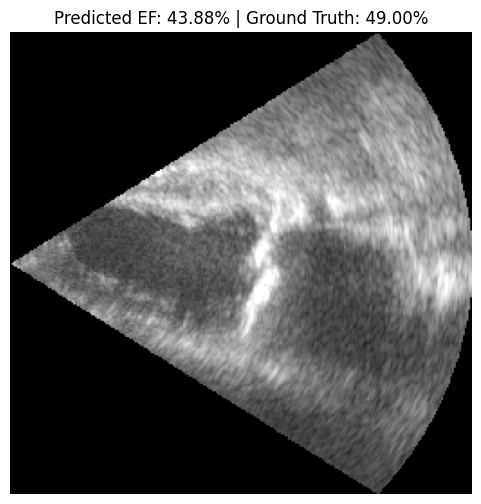

Absolute Error: 5.12%


In [ ]:
import matplotlib.pyplot as plt

def test_prediction(model, dataset, index=0):
    model.eval()    
    img, gt_ef = dataset[index]
    
    # 1. Forward pass (Prediction)
    with torch.no_grad():
        input_img = img.unsqueeze(0).to("cuda")
        pred_ef = model(input_img).item()
    
    # 2. Visualisation
    plt.figure(figsize=(6, 6))
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Predicted EF: {pred_ef:.2f}% | Ground Truth: {gt_ef.item():.2f}%")
    plt.axis('off')
    plt.show()
    
    
    error = abs(pred_ef - gt_ef.item())
    print(f"Absolute Error: {error:.2f}%")

# Test m3a patient random men el 100 samples li l9ina
test_prediction(final_model, ef_dataset, index=10)

In [15]:
import torch

# 1. Path win n-sauvgardiw el models
save_path = r'C:/Users/najib/OneDrive/Bureau/camus_project/models'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 2. Sauvgardi el final model (Position 1 + Position 2)
torch.save(final_model.state_dict(), os.path.join(save_path, 'kan_pfe_model_final.pth'))

print(f"✅ Ga3 el khedma rahi sauvgardiya f: {save_path}")
print("🚀 Ghodwa n-bdaw el Full Training (100 Epochs) bach n-awslo l-el 5% error!")

✅ Ga3 el khedma rahi sauvgardiya f: C:/Users/najib/OneDrive/Bureau/camus_project/models
🚀 Ghodwa n-bdaw el Full Training (100 Epochs) bach n-awslo l-el 5% error!
